# Chronos-2 时序预测——能源价格（含协变量）

使用 Amazon Chronos-2 预测德国未来 24 小时电价，以 **Ampirion 负荷预测** 和 **光伏+风电出力预测** 为已知未来协变量，并与不含协变量的基线对比。

数据：AutoGluon electricity_price（训练集 51936 行，2012-01-09 ~ 2017-12-11，小时级）

预测目标：2017-12-12 00:00 ~ 23:00（24 小时）

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import BaseChronosPipeline, Chronos2Pipeline

plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cpu")

In [2]:
TARGET         = 'target'
ID_COL         = 'id'
TS_COL         = 'timestamp'
TIMESERIES_ID  = 'DE'
PREDICTION_LENGTH = 24
SHOW_HISTORY   = 256

energy_context_df = pd.read_parquet(
    'https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/train.parquet',
    engine='fastparquet'
)
energy_context_df[TS_COL] = pd.to_datetime(energy_context_df[TS_COL])

energy_test_df = pd.read_parquet(
    'https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/test.parquet',
    engine='fastparquet'
)
energy_test_df[TS_COL] = pd.to_datetime(energy_test_df[TS_COL])

# 从测试集移除目标列，仅保留协变量（Chronos-2 通过 future_df 接收已知未来协变量）
energy_future_df = energy_test_df.drop(columns=TARGET)

print('训练数据:', energy_context_df.shape, '| 列:', list(energy_context_df.columns))
print(f'时间范围: {energy_context_df[TS_COL].min().date()} ~ {energy_context_df[TS_COL].max().date()}')
print('预测目标日:', energy_test_df[TS_COL].min().date())
energy_context_df.head(3)

训练数据: (51936, 5) | 列: ['id', 'timestamp', 'target', 'Ampirion Load Forecast', 'PV+Wind Forecast']
时间范围: 2012-01-09 ~ 2017-12-11
预测目标日: 2017-12-12


,id,timestamp,target,Ampirion Load Forecast,PV+Wind Forecast
0,DE,2012-01-09 00:00:00,34.970001,16382.0,3569.527588
1,DE,2012-01-09 01:00:00,33.430000,15410.5,3315.274902
2,DE,2012-01-09 02:00:00,32.740002,15595.0,3107.307617


In [3]:
# 使用协变量预测未来电价
energy_pred_df = pipeline.predict_df(
    energy_context_df,
    future_df=energy_future_df,
    prediction_length=PREDICTION_LENGTH,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column=ID_COL,
    timestamp_column=TS_COL,
    target=TARGET,
)
print('预测结果维度:', energy_pred_df.shape)
energy_pred_df.head()

预测结果维度: (24, 7)


,id,timestamp,target_name,predictions,0.1,0.5,0.9
0,DE,2017-12-12 00:00:00,target,22.242920,18.673723,22.242920,25.403454
1,DE,2017-12-12 01:00:00,target,19.525620,14.904280,19.525620,23.316599
2,DE,2017-12-12 02:00:00,target,17.415373,12.209057,17.415373,21.776979
3,DE,2017-12-12 03:00:00,target,16.979267,11.165129,16.979267,21.435225
4,DE,2017-12-12 04:00:00,target,18.058655,12.096771,18.058655,23.166647


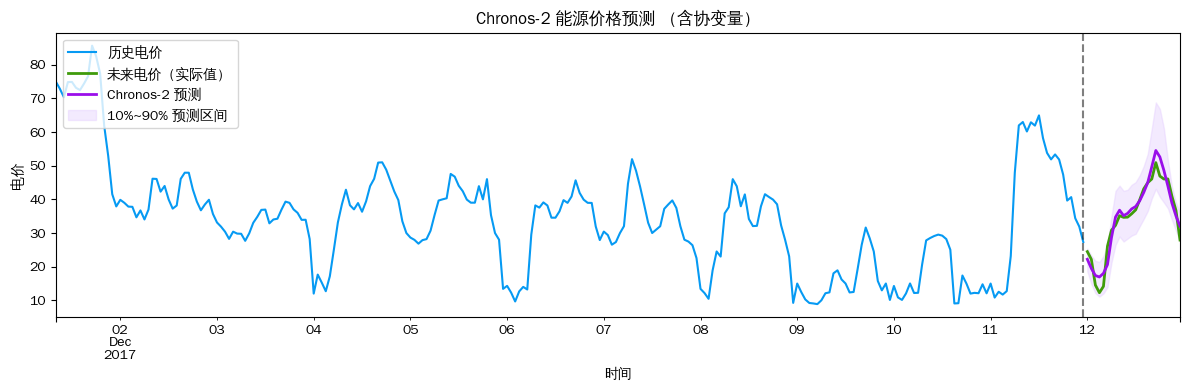

In [4]:
def plot_chronos_energy(context_df, pred_df, test_df, timeseries_id, title_suffix=''):
    ts_ctx  = context_df.query(f"{ID_COL} == @timeseries_id").set_index(TS_COL)[TARGET]
    ts_pred = pred_df.query(f"{ID_COL} == @timeseries_id and target_name == @TARGET").set_index(TS_COL)[['0.1', 'predictions', '0.9']]
    ts_gt   = test_df.query(f"{ID_COL} == @timeseries_id").set_index(TS_COL)[TARGET]

    start_idx = max(0, len(ts_ctx) - SHOW_HISTORY)
    plot_from  = ts_ctx.index[start_idx]
    ts_ctx  = ts_ctx[ts_ctx.index >= plot_from]

    fig, ax = plt.subplots(figsize=(12, 4))
    ts_ctx.plot(ax=ax, label='历史电价', color='xkcd:azure')
    ts_gt.plot(ax=ax,  label='未来电价（实际值）', color='xkcd:grass green', linewidth=2)
    ts_pred['predictions'].plot(ax=ax, label='Chronos-2 预测', color='xkcd:violet', linewidth=2)
    ax.fill_between(ts_pred.index, ts_pred['0.1'], ts_pred['0.9'],
                    alpha=0.35, label='10%~90% 预测区间', color='xkcd:light lavender')
    ax.axvline(x=context_df.query(f"{ID_COL} == @timeseries_id")[TS_COL].max(),
               color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'Chronos-2 能源价格预测 {title_suffix}')
    ax.set_xlabel('时间')
    ax.set_ylabel('电价')
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

plot_chronos_energy(energy_context_df, energy_pred_df, energy_test_df,
                    TIMESERIES_ID, title_suffix='（含协变量）')

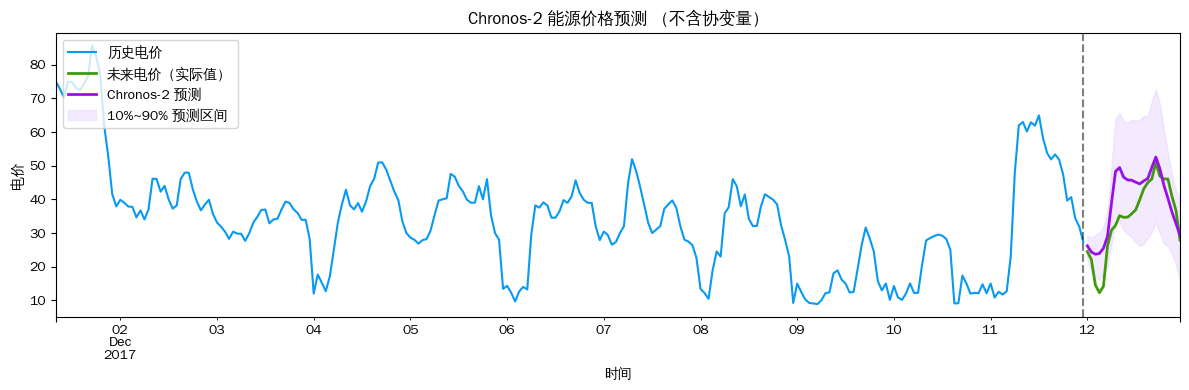

In [5]:
# 对比：不含协变量的基线
energy_pred_no_cov = pipeline.predict_df(
    energy_context_df[[ID_COL, TS_COL, TARGET]],
    future_df=None,
    prediction_length=PREDICTION_LENGTH,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column=ID_COL,
    timestamp_column=TS_COL,
    target=TARGET,
)

plot_chronos_energy(energy_context_df, energy_pred_no_cov, energy_test_df,
                    TIMESERIES_ID, title_suffix='（不含协变量）')

In [7]:
# 误差指标对比
gt = (energy_test_df.query(f"{ID_COL} == @TIMESERIES_ID")
      .sort_values(TS_COL)[TARGET].values)

def calc_metrics(pred_df, timeseries_id, label):
    y_pred = pred_df.query(f"{ID_COL} == @timeseries_id and target_name == @TARGET").sort_values(TS_COL)['predictions'].values
    mae  = np.mean(np.abs(gt - y_pred))
    rmse = np.sqrt(np.mean((gt - y_pred) ** 2))
    mape = np.mean(np.abs((gt - y_pred) / gt)) * 100
    print(f'{label}  MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%')

print('─' * 55)
calc_metrics(energy_pred_df,        TIMESERIES_ID, 'Chronos-2 含协变量:  ')
calc_metrics(energy_pred_no_cov,    TIMESERIES_ID, 'Chronos-2 不含协变量:')
print('─' * 55)

───────────────────────────────────────────────────────
Chronos-2 含协变量:    MAE=2.457  RMSE=2.886  MAPE=9.26%
Chronos-2 不含协变量:  MAE=6.314  RMSE=7.759  MAPE=24.01%
───────────────────────────────────────────────────────
